In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

import time
!pip install python-docx
from docx import Document
from docx.shared import Inches

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 1.3 MB/s eta 0:00:00


In [ ]:
#Reading df_basic
df_name = 'df_basic_1.2' # images are min max normalised, resized (64,64) and grey

drive.mount('/content/drive')
df_basic = pd.read_pickle("/content/drive/My Drive/Team Project X-Rays/Dataframes/df_basic_1.2.pkl")
# Setting the image name as Index and display the first 5 lines
df_basic = df_basic.set_index('Name')
df_basic.head()

Mounted at /content/drive


,Case,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
Name,,,,,,,,,,,,,,,,,,,,,
COVID-1240,COVID,0.152074,0.152074,0.258065,0.585253,0.585253,0.557604,0.156682,0.156682,0.152074,...,0.889401,0.801843,0.718894,0.608295,0.437788,0.622120,0.751152,0.870968,0.861751,1.000000
COVID-1508,COVID,0.012346,0.012346,0.008230,0.008230,0.008230,0.008230,0.008230,0.008230,0.008230,...,0.436214,0.296296,0.098765,0.053498,0.008230,0.012346,0.012346,0.012346,0.012346,0.012346
COVID-1153,COVID,0.049020,0.053922,0.019608,0.269608,0.289216,0.147059,0.210784,0.049020,0.039216,...,0.661765,0.637255,0.612745,0.588235,0.539216,0.529412,0.465686,0.431373,0.446078,0.387255
COVID-1984,COVID,0.008584,0.034335,0.124464,0.206009,0.274678,0.326180,0.403433,0.442060,0.480687,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004292
COVID-3351,COVID,0.075314,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.832636,0.824268,0.765690,0.702929,0.589958,0.435146,0.238494,0.004184,0.004184,0.694561


In [ ]:
# Encode classes as numbers (LabelEncoder)
le = LabelEncoder()
df_basic['Case'] = le.fit_transform(df_basic['Case'])

# Splitting data into features (X) and target (y)
X = df_basic.drop('Case', axis=1)
y = df_basic['Case']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)


**PCA (Principal component analysis)**

In [ ]:
### --- PCA (Principal component analysis) --- ###

# Instantiating a PCA object (It shall generate as many components that are needed in order to explain 90 % of the datas variability)
pca = PCA(n_components = 0.9)

# Fit and transform the data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


The number of components needed to explain 90 % of the datas variability are: 62
The first two components explain 37.0 % of the variability.


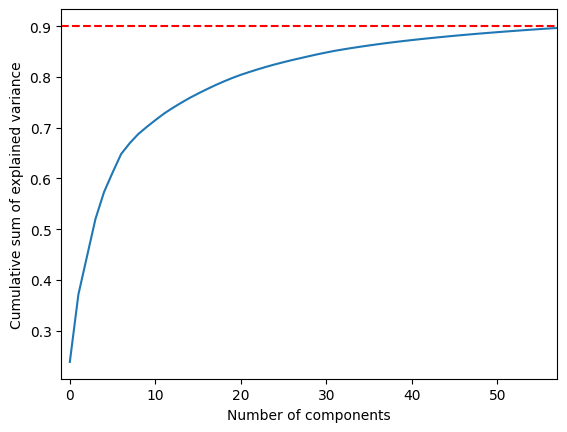

In [ ]:
# Report of how many dimensions are necessary to keep the majority of the informational content
print(f'The number of components needed to explain 90 % of the datas variability are: {pca.n_components_}')
print(f"The first two components explain {round(pca.explained_variance_ratio_[0:2].sum(),2)*100} % of the variability.")

# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 57)
plt.xlabel('Number of components')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

# Save image as .png
plt.savefig(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png', bbox_inches = 'tight')


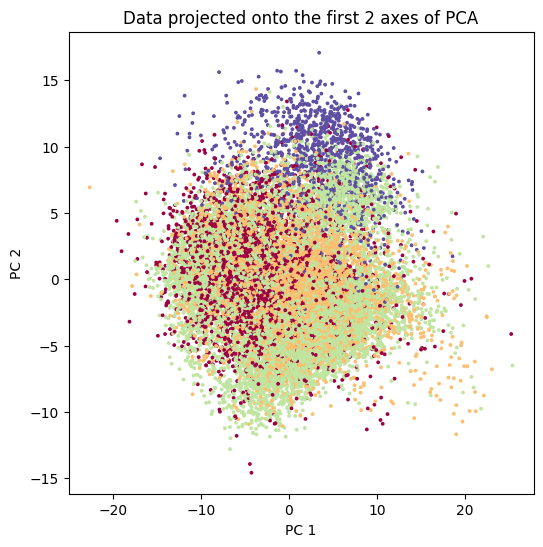

In [ ]:
# Plot the observations using the first two components of the PCA
plt.figure(figsize = (6,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c = y_train, s = 3, cmap=plt.cm.Spectral);
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.title("Data projected onto the first 2 axes of PCA")

# Save image as .png
plt.savefig(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png', bbox_inches = 'tight')


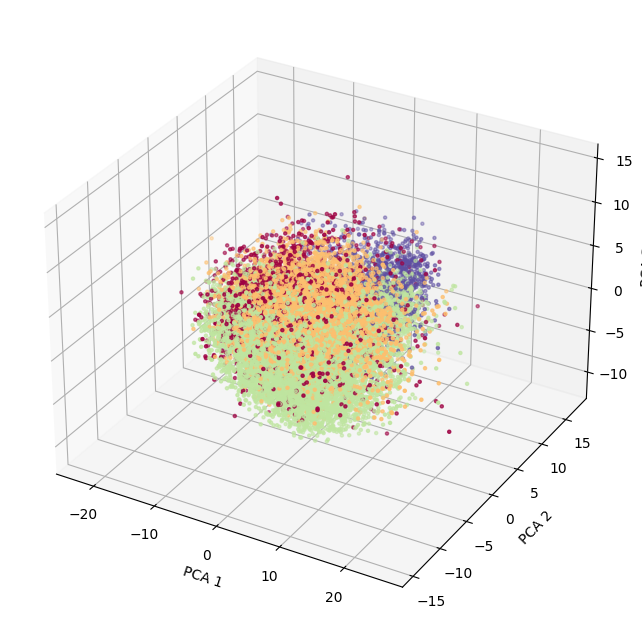

In [ ]:
# 3D plot of the first 3 principle components
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_pca[:,0], X_train_pca[:,1], X_train_pca[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

# Save image as .png
plt.savefig(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png', bbox_inches = 'tight')


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
PC1,-0.000023,-0.000987,-0.000722,-0.000161,0.000044,0.000273,0.000451,0.000675,0.000771,0.000614,...,-0.021171,-0.023042,-0.024792,-0.025876,-0.026359,-0.026022,-0.024596,-0.022420,-0.020447,-0.018157
PC2,0.004263,0.009915,0.012898,0.014618,0.015935,0.017644,0.019134,0.020299,0.021179,0.021847,...,-0.006976,-0.007845,-0.009298,-0.011156,-0.013425,-0.015344,-0.016128,-0.015203,-0.013458,-0.014150
PC3,-0.017443,-0.012153,-0.011414,-0.011916,-0.012539,-0.012551,-0.012398,-0.012662,-0.012642,-0.012755,...,0.014919,0.018003,0.020871,0.023886,0.026055,0.027402,0.027588,0.026928,0.024235,0.017664
PC4,0.006934,0.002615,0.001768,0.001686,0.001649,0.001821,0.001702,0.001739,0.002091,0.002150,...,0.021260,0.023145,0.024186,0.024391,0.023127,0.020756,0.017209,0.012982,0.009153,0.007765
PC5,0.007385,0.014416,0.016500,0.017463,0.018464,0.019205,0.019963,0.020476,0.021070,0.021589,...,0.022996,0.029467,0.036116,0.042068,0.045621,0.047388,0.046820,0.044444,0.039497,0.028363


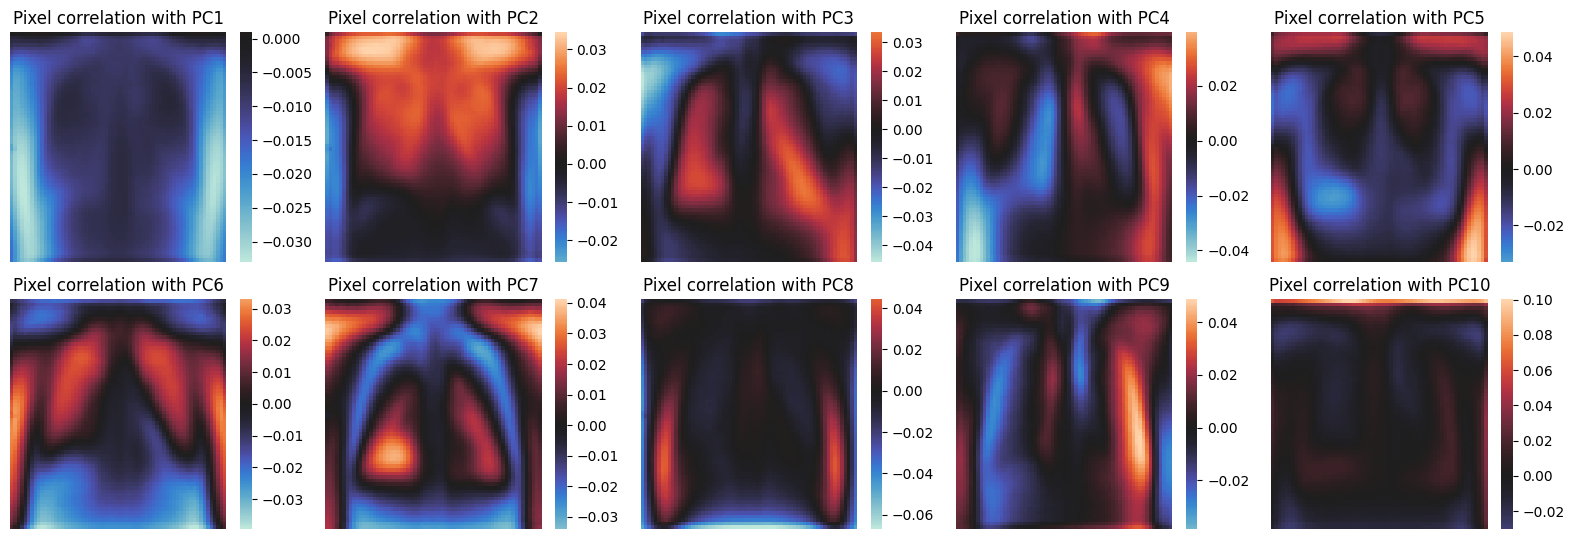

In [ ]:
### --- Interpretation of PCA (which parts of the images are important) --- ###

# Get the correlations of each pixel to the 57 PCs and create a dataframe with this information (rows = PCs, columns = PXs)
corr_df = pd.DataFrame(pca.components_[0:pca.components_.shape[0]+1,:], columns= X.columns, index = [f'PC{i+1}' for i in range(pca.components_.shape[0])])
display(corr_df.head())

# Convert rows of corr_df to a image-shaped numpy array (64,64)
def row_to_image_array (df, number_PCA):
  # Convert row to a numpy array
  row_as_array = corr_df.iloc[number_PCA].values
  # Reshape the numpy array to our current image size (64x64)
  reshaped_array = np.reshape(row_as_array, (64, 64))
  return reshaped_array

# Plotting the correlation of each pixel with the first 10 PCs as an image shaped heat-map in a 2x5 raster
# Define colormap
sns.color_palette("icefire", as_cmap=True)
# Create the subplot grid
fig, axes = plt.subplots(2, 5, figsize=(16, 5.5))

for i in np.arange(0,10):
    # Generate the reshaped array for row i
    reshaped_array = row_to_image_array(corr_df, i)
    # Define position in the subplot grid
    ax = axes[i // 5, i % 5]
    # Plot the heatmap
    sns.heatmap(reshaped_array, ax=ax,  center=0, cmap='icefire')
    ax.set_title(f'Pixel correlation with PC{i+1}')
    ax.axis('off')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png', bbox_inches = 'tight')


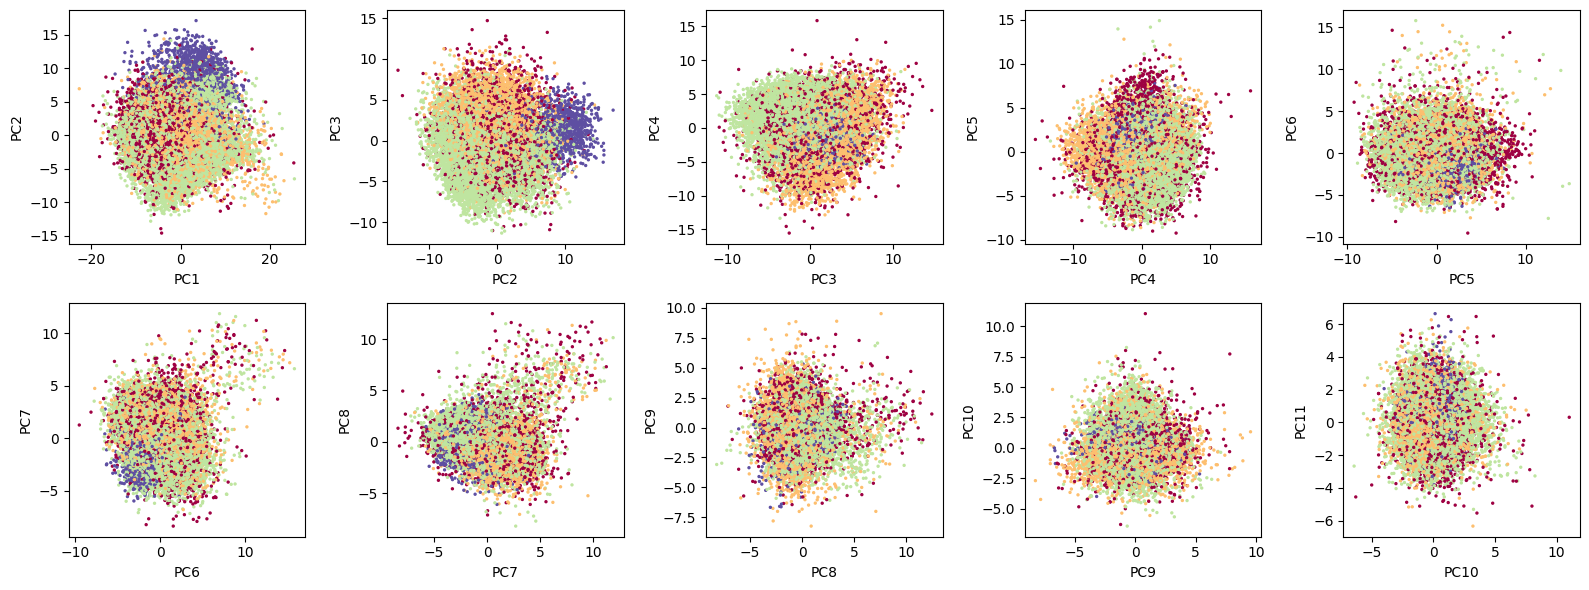

In [ ]:
# Plot the observations projected onto the different PC axes in decreasing order/importance
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i in np.arange(0,10):
    ax = axes[i // 5, i % 5]
    ax.scatter(X_train_pca[:, i], X_train_pca[:, i+1], c=y_train, s=2, cmap=plt.cm.Spectral);
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{i+2}')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png', bbox_inches = 'tight')


**LDA (Linear discriminant analysis)**

In [ ]:
### --- LDA (Linear discriminant analysis) --- ###

lda = LDA()
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)


In [ ]:
# Print the shape
X_train_lda.shape


(16884, 3)

Train score: 0.8621179815209666
Test score: 0.687514806917792


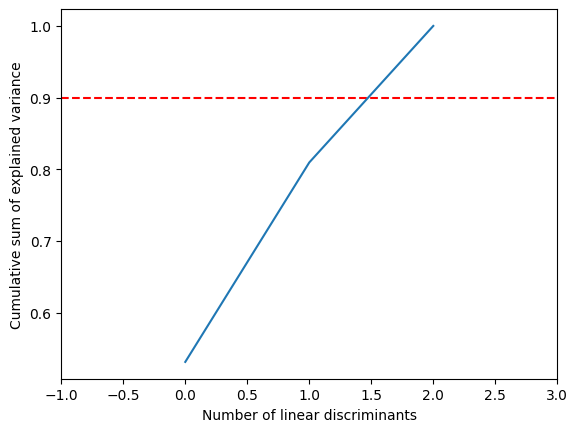

In [ ]:
# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 3)
plt.xlabel('Number of linear discriminants')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(lda.explained_variance_ratio_.cumsum())

# Save image as .png
plt.savefig(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png', bbox_inches = 'tight')

# Assess the score of 'LDA classification'
print(f'Train score: {lda.score(X_train, y_train)}')
print(f'Test score: {lda.score(X_test, y_test)}')

The first two components explain 80.9 % of the variability.


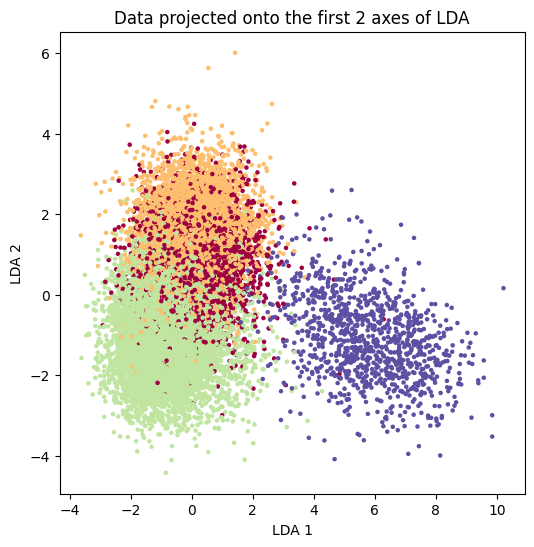

In [ ]:
# Report the explained variance for the first two components
print(f"The first two components explain {round(lda.explained_variance_ratio_[0:2].sum(),3)*100} % of the variability.")

# Plot the observations using the first two components of the LDA
plt.figure(figsize = (6,6))
plt.scatter(X_train_lda[:,0], X_train_lda [:,1], c = y_train, s = 5, cmap=plt.cm.Spectral);
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')

plt.title("Data projected onto the first 2 axes of LDA")

# Save image as .png
plt.savefig(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png', bbox_inches = 'tight')


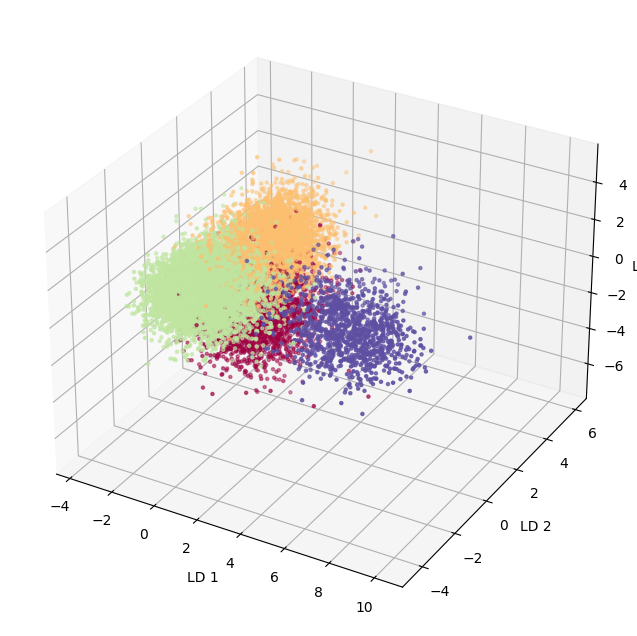

In [ ]:
# 3D plot of all 3 linear discriminants
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_lda[:,0], X_train_lda[:,1], X_train_lda[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('LD 1')
ax.set_ylabel('LD 2')
ax.set_zlabel('LD 3')

# Save image as .png
plt.savefig(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png', bbox_inches = 'tight')


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
PC1,-0.555320,0.171492,-0.133202,-0.524531,-2.772874,3.639026,-3.055798,0.108836,1.377172,1.530250,...,-0.639316,-0.065172,0.921644,-1.667220,0.830509,-0.582261,0.484275,1.647581,-4.124167,5.691895
PC2,0.273883,1.526185,-0.371472,-0.752763,0.889738,0.443997,-0.196702,-0.217849,-1.003393,0.278041,...,1.092540,-0.959128,0.792170,-0.449643,0.011620,0.376406,-0.143850,0.053737,-0.236501,-0.056462
PC3,-0.461252,0.186457,-1.080981,0.796916,1.282612,-0.632124,0.350543,-0.568534,0.300682,-0.673805,...,0.309189,-0.226031,-0.300329,0.178226,-0.483703,-0.105623,0.871659,-0.817251,1.982111,-1.584251
PC4,3.750279,-8.580851,10.144597,-1.304310,-6.222730,-6.858196,6.343703,4.958912,-1.512064,-0.207987,...,-5.442704,6.100602,-3.671141,5.066276,1.390554,0.687581,-7.230101,1.549747,-2.950478,-2.928579


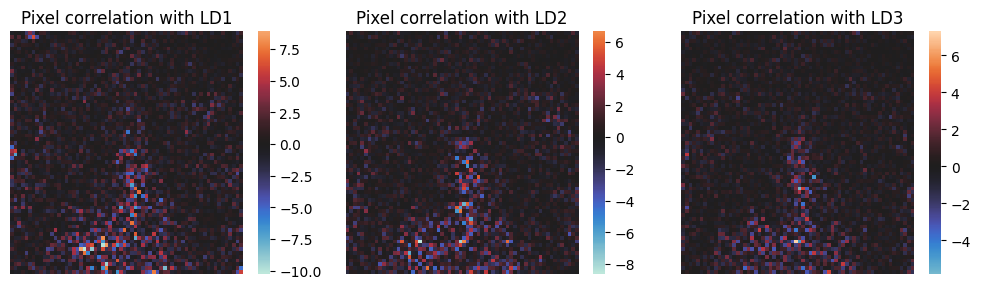

In [ ]:
### --- Interpretation of LDA (which parts of the images are important) --- ###

# Get the correlations of each pixel to the 3 PCs and create a dataframe with this information (rows = LDs, columns = PXs)
corr_df = pd.DataFrame(lda.coef_[0:lda.coef_.shape[0]+1,:], columns= X.columns, index = [f'PC{i+1}' for i in range(lda.coef_.shape[0])])
display(corr_df.head())

# Convert rows of corr_df to a image-shaped numpy array (64,64)
def row_to_image_array (df, number_LDA):
  # Convert row to a numpy array
  row_as_array = corr_df.iloc[number_LDA].values
  # Reshape the numpy array to our current image size (64x64)
  reshaped_array = np.reshape(row_as_array, (64, 64))
  return reshaped_array

# Plotting the correlation of each pixel with the first 10 PCs as an image shaped heat-map in a 2x5 raster
# Define colormap
sns.color_palette("icefire", as_cmap=True)
# Create the subplot grid
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in np.arange(0,3):
    # Generate the reshaped array for row i
    reshaped_array = row_to_image_array(corr_df, i)
    # Define position in the subplot grid
    ax = axes[i]
    # Plot the heatmap
    sns.heatmap(reshaped_array, ax=ax,  center=0, cmap='icefire')
    ax.set_title(f'Pixel correlation with LD{i+1}')
    ax.axis('off')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png', bbox_inches = 'tight')


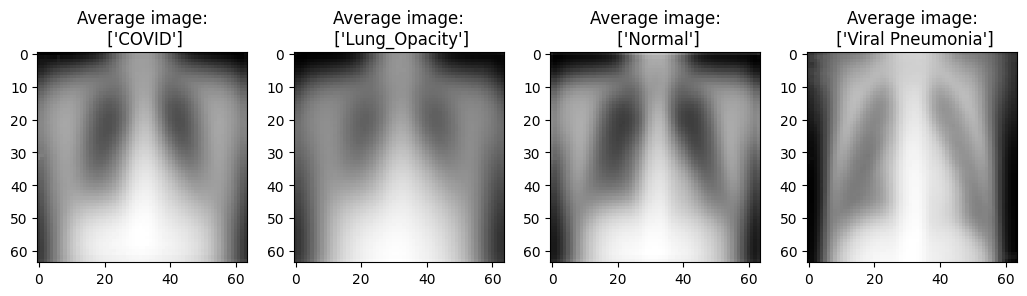

In [ ]:
# Generating and displaying the average image of each class
X_array = X.to_numpy()
y_array = y.to_numpy()

plt.figure(figsize = (16,6))
for i in np.arange(0,4):
    indices = np.where(y==i)[0]
    average_image = X_array[indices].mean(axis=0)
    reshaped_average_image = np.reshape(average_image, (64, 64))
    plt.subplot(2,5, i+1)
    plt.imshow(reshaped_average_image, cmap='gray')
    plt.title(f'Average image:\n {le.inverse_transform([i])}')

# Save image as .png
plt.savefig(f'/content/Average image of each class_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Generate random data for test purposes
np.random.seed(0)  # For reproducibility
data = np.random.randn(100, 9)  # 9 feature columns

# Create target column with integers 1-4
target = np.random.randint(1, 5, size=(100, 1))

# Concatenate target and feature columns
data = np.hstack((target, data))

# Create a DataFrame
df = pd.DataFrame(data, columns=['target'] + [f'feature_{i}' for i in range(9)])
display(df.head())

# Encode classes as numbers (LabelEncoder)
lenc = LabelEncoder()
df['target'] = lenc.fit_transform(df['target'])

data = df.drop('target', axis=1)
target = df['target']

# Splitting data into training and testing sets
X_train__check, X_test__check, y_train_check, y_test_check = train_test_split(data, target, test_size=0.2)


,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8
0,3.0,1.764052,0.400157,0.978738,2.240893,1.867558,-0.977278,0.950088,-0.151357,-0.103219
1,4.0,0.410599,0.144044,1.454274,0.761038,0.121675,0.443863,0.333674,1.494079,-0.205158
2,2.0,0.313068,-0.854096,-2.552990,0.653619,0.864436,-0.742165,2.269755,-1.454366,0.045759
3,2.0,-0.187184,1.532779,1.469359,0.154947,0.378163,-0.887786,-1.980796,-0.347912,0.156349
4,3.0,1.230291,1.202380,-0.387327,-0.302303,-1.048553,-1.420018,-1.706270,1.950775,-0.509652


In [ ]:
### --- Test predictive performance with different techniques of dimension reduction applied to the data set --- ###

# Setting up four different models
lr = LogisticRegression(solver='lbfgs', C = 1.0, max_iter=10000)
knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
svc = SVC(gamma = 0.01, kernel = "poly")
dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=123)

# Define function to test model performance
def test_performance(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    cl_report = classification_report(y_te, model.predict(X_te), output_dict=True)
    cl_report_df = pd.DataFrame(cl_report).transpose()
    f1_scores_covid = cl_report_df.iloc[0]['f1-score']
    f1_score_opacity = cl_report_df.iloc[1]['f1-score']
    f1_score_normal = cl_report_df.iloc[2]['f1-score']
    f1_score_pneumonia = cl_report_df.iloc[3]['f1-score']
    return model.score(X_train, y_train), model.score(X_test, y_test), f1_scores_covid, f1_score_opacity, f1_score_normal, f1_score_pneumonia


# Create list of data sets to be analysed
datasets = [
    (X_train, X_test, y_train, y_test, 'No dimension reduction'),
    (X_train_pca, X_test_pca, y_train, y_test, 'PCA'),
    (X_train_lda, X_test_lda, y_train, y_test, 'LDA'),
    #(X_train__check, X_test__check, y_train_check, y_test_check, 'check')
    ]

# Create list of models to be tested
models = [(lr, 'LogisticRegression'), (knn, 'KNeighbors'), (svc, 'SVC'), (dt, 'DecisionTree')]

# Create empty lists to store results
model_names =[]
dataset_names = []
model_scores = []
execution_times = []

# Loop through the different models and data sets to determine the
# performance of each model on each test set
for model, model_name in models:
  for X_tr, X_te, y_tr, y_te, dataset_name in datasets:
    # Add model name to list
    model_names.append(model_name)
    # Add dataset name to the list
    dataset_names.append(dataset_name)
    # Record the start time
    start_time = time.time()
    # Fit model and calculate train and test score
    model_scores.append(test_performance(X_tr, X_te, y_tr, y_te,model))
    # Record the end time
    end_time = time.time()
    # Calculate the execution time
    execution_time = (end_time - start_time)/60
    # Add execution time to the list
    execution_times.append(execution_time)

# Create a DataFrame with the results and display it
results = pd.DataFrame({'Model': model_names, 'Dataset': dataset_names, 'Train_accuracy': np.array(model_scores)[:,0], 'Test_accuracy': np.array(model_scores)[:,1], 'f1_covid' : np.array(model_scores)[:,2],
                        'f1_lung_opacity' : np.array(model_scores)[:,3], 'f1_normal' : np.array(model_scores)[:,4], 'f1_pneumonia' : np.array(model_scores)[:,5], 'f1_mean' : np.array(model_scores)[:,2:6].mean(axis=1), 'Execution time [min]': execution_times})
display(results)


,Model,Dataset,Train_accuracy,Test_accuracy,f1_covid,f1_lung_opacity,f1_normal,f1_pneumonia,f1_mean,Execution time [min]
0,LogisticRegression,No dimension reduction,0.872364,0.718076,0.531394,0.661437,0.793726,0.841897,0.707113,46.997634
1,LogisticRegression,PCA,0.720860,0.717366,0.461538,0.682927,0.791370,0.829077,0.691228,0.035099
2,LogisticRegression,LDA,0.865257,0.686330,0.519882,0.625359,0.765301,0.780684,0.672807,0.002359
3,KNeighbors,No dimension reduction,0.820718,0.771855,0.615760,0.721195,0.837431,0.868476,0.760716,2.554023
4,KNeighbors,PCA,0.822554,0.776593,0.630048,0.726686,0.839181,0.858333,0.763562,0.073620
5,KNeighbors,LDA,0.875267,0.678749,0.518996,0.616327,0.757376,0.786290,0.669747,0.027252
6,SVC,No dimension reduction,1.000000,0.800995,0.699109,0.752301,0.852323,0.910537,0.803567,27.707720
7,SVC,PCA,0.907013,0.813788,0.697565,0.775139,0.864448,0.885312,0.805616,0.751492
8,SVC,LDA,0.621061,0.568349,0.215881,0.221916,0.691199,0.754717,0.470928,0.279767
9,DecisionTree,No dimension reduction,0.651386,0.645345,0.303327,0.564950,0.753676,0.619165,0.560280,1.027382


In [ ]:
# Save the DataFrame as a CSV file
results.to_excel(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx', index=False)

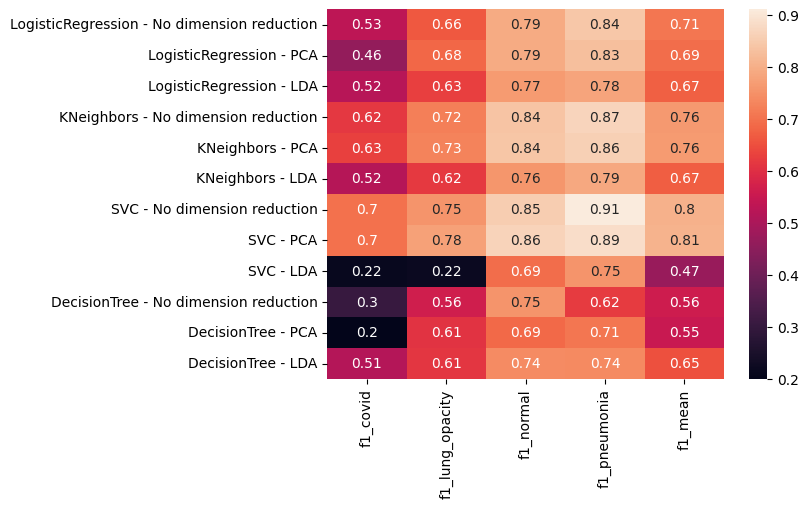

In [ ]:
# Create a heatmap for visual interpretation
orange_pallet = sns.color_palette("YlOrBr", as_cmap=True)
sns.heatmap(results[['f1_covid', 'f1_lung_opacity', 'f1_normal', 'f1_pneumonia', 'f1_mean']], yticklabels= results['Model']+' - '+results['Dataset'], annot = True)#, cmap = 'dark:salmon_r')

# Save image as .png
plt.savefig(f'/content/Heatmap_model_performance_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Insert grafics in word-docx
# Create a word document
doc = Document()

# Create a heading
doc.add_heading(f'The impact of dimension reduction - Images for the analysis of {df_name}', 0)

# Add graphs to the document
doc.add_picture(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
doc.add_picture(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
doc.add_picture(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
doc.add_picture(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
doc.add_picture(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
doc.add_picture(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
doc.add_picture(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
doc.add_picture(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/Average image of each class_{df_name}.png')
doc.add_picture(f'/content/Heatmap_model_performance_{df_name}.png')

# Save word document
doc.save(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')



In [ ]:
# Downloads
files.download(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
files.download(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
files.download(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
files.download(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
files.download(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
files.download(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
files.download(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
files.download(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/Average image of each class_{df_name}.png')
files.download(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx')
files.download(f'/content/Heatmap_model_performance_{df_name}.png')
files.download(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>